# BERTopic — soft clustering (per-document topic weights)

The base notebook (`1.0`) gives each headline a single **hard** topic label. Here we
want a **soft** assignment: a *weight per document per topic*, so a headline can belong
partly to several themes. BERTopic exposes two different ways to get this:

| method | what the weight means | cost | scales to 100k? |
|--------|----------------------|------|-----------------|
| **HDBSCAN soft membership** (`calculate_probabilities=True`) | probability the doc belongs to each topic, from the density clustering | slow, memory-heavy (`all_points_membership_vectors`) | risky |
| **`approximate_distribution`** | how much of each topic's c-TF-IDF vocabulary appears in the doc (token-level) | batched, light | yes |

Both return a dense `(n_docs × n_topics)` matrix. We run on the **1,000/year (10k-doc)**
sample, where the HDBSCAN path is fast and stays well under ~1 GB. For the full
100k-doc corpus, prefer `approximate_distribution` (see the note at the end).

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import torch
from bertopic import BERTopic
from hdbscan import HDBSCAN
from umap import UMAP
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PER_YEAR = 1000  # 10k docs — safe for HDBSCAN soft clustering on 8 GB RAM
SAMPLE_PATH = PROJECT_ROOT / "data" / "processed" / f"sample_{PER_YEAR}_per_year.parquet"

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
RANDOM_SEED = 42

DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("device:", DEVICE)

device: mps


## 1. Load sample & embed

Same corpus and embeddings as `1.0`. Build the sample first if it's missing:

```bash
uv run python scripts/build_sample.py --per-year 1000
```

In [2]:
assert SAMPLE_PATH.exists(), (
    f"{SAMPLE_PATH} missing — run: uv run python scripts/build_sample.py --per-year {PER_YEAR}"
)

corpus = pd.read_parquet(SAMPLE_PATH).drop_duplicates(subset="Headline").reset_index(drop=True)
docs = corpus["Headline"].tolist()

embedder = SentenceTransformer(EMBEDDING_MODEL, device=DEVICE)
embeddings = np.asarray(embedder.encode(docs, batch_size=64, show_progress_bar=True), dtype="float64")
print(f"{len(docs):,} docs, embeddings {embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

10,000 docs, embeddings (10000, 384)


## 2. Fit with `calculate_probabilities=True`

The single switch that turns on soft clustering. It needs `prediction_data=True` on
HDBSCAN (set below). `fit_transform` now returns a 2-D `probs` matrix instead of a
1-D vector of max-probabilities.

In [3]:
topic_model = BERTopic(
    embedding_model=embedder,
    umap_model=UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=RANDOM_SEED),
    hdbscan_model=HDBSCAN(min_cluster_size=10, min_samples=5, metric="euclidean",
                          cluster_selection_method="eom", prediction_data=True),
    vectorizer_model=CountVectorizer(stop_words="english", ngram_range=(1, 2)),
    calculate_probabilities=True,   # <-- soft clustering
    verbose=True,
)
topics, probs = topic_model.fit_transform(docs, embeddings=embeddings)

n_topics = (topic_model.get_topic_info()["Topic"] != -1).sum()
print(f"probs matrix: {probs.shape}  (n_docs x n_topics={n_topics})  dtype={probs.dtype}")
print(f"memory: {probs.nbytes / 1e6:.0f} MB")

2026-06-22 09:35:24,408 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-06-22 09:35:45,830 - BERTopic - Dimensionality - Completed ✓


2026-06-22 09:35:45,841 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-06-22 09:35:55,281 - BERTopic - Cluster - Completed ✓


2026-06-22 09:35:55,302 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-06-22 09:35:55,640 - BERTopic - Representation - Completed ✓


probs matrix: (10000, 197)  (n_docs x n_topics=197)  dtype=float64
memory: 16 MB


> **Reading the matrix.** `probs[i, j]` is the membership weight of document *i* in
> topic *j* (topics are columns `0..n_topics-1`; the outlier topic `-1` has no column).
> Rows do **not** sum to 1 — HDBSCAN memberships are independent per topic, so a clear
> outlier can have low weight everywhere, and an ambiguous doc can score on several.

In [4]:
# Per-document: hard label vs the soft weights it's torn between.
def soft_label(i, top=3):
    order = np.argsort(probs[i])[::-1][:top]
    return ", ".join(f"T{j}={probs[i, j]:.2f}" for j in order if probs[i, j] > 0)

view = pd.DataFrame({
    "headline": [d[:70] for d in docs],
    "hard_topic": topics,
    "max_weight": probs.max(axis=1).round(3),
    "top_soft_topics": [soft_label(i) for i in range(len(docs))],
})
# The interesting cases are the *ambiguous* docs — split across multiple topics.
print("Most ambiguous headlines (highest 2nd-best weight):")
second_best = np.sort(probs, axis=1)[:, -2]
view.assign(second=second_best).sort_values("second", ascending=False).head(10)

Most ambiguous headlines (highest 2nd-best weight):


,headline,hard_topic,max_weight,top_soft_topics,second
6147,Gamida Cell Ltd.: 3 2022-01-01,153,0.183,"T153=0.18, T154=0.11, T40=0.05",0.106437
2508,EON: Biogen Foundation Commits $10 Million to ...,50,0.110,"T50=0.11, T40=0.10, T154=0.04",0.103714
2106,Galena Biopharma Announces Expansion of Scient...,-1,0.123,"T154=0.12, T153=0.10, T40=0.06",0.097710
2967,CharlotteObservr: The Latest: HTC has new head...,159,0.103,"T159=0.10, T149=0.10, T179=0.05",0.096180
7453,Salt Lake Trib: Paul Krugman: House Republican...,-1,0.152,"T68=0.15, T189=0.09, T51=0.04",0.088958
2705,"Axogen, Inc.: 8-K 2017/12/29",-1,0.112,"T153=0.11, T154=0.09, T40=0.03",0.088444
4514,Derbyshire Live: Burton toddler murder among s...,85,0.111,"T85=0.11, T120=0.09, T15=0.03",0.086536
4478,Oxford Instr: Texas Society for Microscopy - F...,154,0.154,"T154=0.15, T153=0.08, T40=0.04",0.084055
8342,*QUALCOMM UNVEILS CHIP TO POWER MIXED-REALITY ...,-1,0.089,"T149=0.09, T159=0.08, T179=0.05",0.083403
7461,news.com.au: U.S. House adjourns for 3rd day w...,-1,0.103,"T68=0.10, T189=0.08, T51=0.04",0.083349


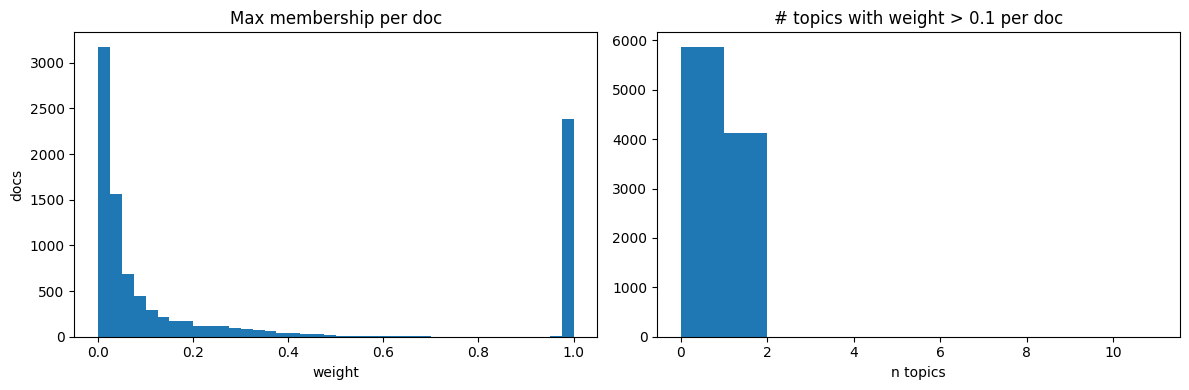

In [5]:
# Distribution of confidence: how peaked is each doc's assignment?
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(probs.max(axis=1), bins=40)
ax[0].set(title="Max membership per doc", xlabel="weight", ylabel="docs")
ax[1].hist((probs > 0.1).sum(axis=1), bins=range(0, 12))
ax[1].set(title="# topics with weight > 0.1 per doc", xlabel="n topics")
plt.tight_layout()

## 3. `approximate_distribution` — the scalable alternative

Instead of density membership, this slides a window over each document's tokens and
measures how much each topic's c-TF-IDF vocabulary is present. It's batched
(`batch_size`) so memory is bounded, works on the online path too, and is the
recommended route for the full 100k-doc corpus.

In [6]:
topic_distr, _ = topic_model.approximate_distribution(docs, batch_size=1000)
print("approx distribution:", topic_distr.shape)

# Same "what is this doc about" view, token-distribution style.
i = int(np.argmax(second_best))  # reuse the most-ambiguous doc from above
print("\nHeadline:", docs[i])
order = np.argsort(topic_distr[i])[::-1][:5]
for j in order:
    if topic_distr[i, j] > 0:
        words = ", ".join(w for w, _ in topic_model.get_topic(j)[:5])
        print(f"  T{j}={topic_distr[i, j]:.2f}  ({words})")

  0%|          | 0/10 [00:00<?, ?it/s]

 30%|███       | 3/10 [00:00<00:00, 28.48it/s]

 60%|██████    | 6/10 [00:00<00:00, 27.03it/s]

 90%|█████████ | 9/10 [00:00<00:00,  8.22it/s]

100%|██████████| 10/10 [00:00<00:00, 10.78it/s]

approx distribution: (10000, 197)

Headline: Gamida Cell Ltd.: 3 2022-01-01
  T153=0.37  (biopharma, pharmaceuticals, takeda pharmaceutical, pharmaceuticals 2024, takeda)
  T1=0.25  (01, 01 02, 02, 12, 01 01)
  T9=0.14  (corp, 01, 01 03, 2024 01, 12)
  T154=0.08  (isracann, schaeffler, bitalpha ai, bitalpha, biosciences)
  T42=0.08  (financial, bancorp, financial corp, corp, bankshares)


BERTopic can also visualise one document's topic distribution directly:

In [7]:
topic_model.visualize_distribution(topic_distr[i], min_probability=0.0)

## 4. Save the soft assignments

Persist the weight matrix alongside the headlines so downstream work (theme scoring,
overlap analysis) can reuse it without refitting.

In [8]:
OUT = PROJECT_ROOT / "data" / "processed" / f"soft_clusters_{PER_YEAR}_per_year.parquet"
soft_df = pd.concat([
    corpus[["Headline", "CaptureTime", "year"]].reset_index(drop=True),
    pd.Series(topics, name="hard_topic"),
    pd.DataFrame(probs, columns=[f"topic_{j}" for j in range(probs.shape[1])]),
], axis=1)
soft_df.to_parquet(OUT, index=False)
print(f"wrote {soft_df.shape} -> {OUT.relative_to(PROJECT_ROOT)}")

wrote (10000, 201) -> data/processed/soft_clusters_1000_per_year.parquet


## Notes & next steps

- **Rows don't sum to 1** (HDBSCAN membership). If you need a probability *simplex* per
  doc, normalise rows, or use `approximate_distribution`, whose rows are closer to a
  distribution.
- **Scaling to 100k:** `calculate_probabilities=True` runs `all_points_membership_vectors`,
  which gets slow/heavy fast. On the full corpus use `approximate_distribution` (batched)
  instead, or keep soft clustering on a sampled subset.
- **Outliers:** docs labelled `-1` have no column; a low `max_weight` row is effectively
  "no strong theme" — useful as a filter.